# 04. Evaluation & Results Comparison

This notebook covers the evaluation and comparison of the trained models:
- Load the predictions generated in notebook 3.
- Compute MAE, RMSE, and MAPE for each model.
- Generate a model comparison table and save it to `results/metrics.csv`.
- Visualize the true target values vs predictions and save the plot to `figures/`.

In [1]:
import sys
sys.path.append('../')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.evaluation import calculate_metrics

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)

## 1. Load Predictions

In [2]:
predictions_path = "../results/predictions.csv"
pred_df = pd.read_csv(predictions_path)
pred_df["date"] = pd.to_datetime(pred_df["date"])
pred_df.head()

,date,y_true,naive,moving_average,linear_regression_baseline,linear_regression_fourier,xgboost,lstm
0,2018-03-12 00:00:00,-1.000025,-1.044511,-1.082733,-1.063757,-1.098185,-1.051748,-1.014611
1,2018-03-12 01:00:00,-1.008960,-1.000219,-1.075560,-1.020245,-1.054245,-1.015978,-0.977215
2,2018-03-12 02:00:00,-1.053255,-1.009153,-1.069523,-1.024171,-1.050664,-1.015978,-0.942210
3,2018-03-12 03:00:00,-1.044320,-1.053445,-1.065751,-1.067842,-1.081980,-1.044994,-0.932602
4,2018-03-12 04:00:00,-1.008960,-1.044511,-1.061599,-1.063772,-1.068764,-1.051603,-0.989622


## 2. Compute Metrics

In [3]:
y_true = pred_df["y_true"].values
models = [col for col in pred_df.columns if col not in ["date", "y_true"]]

metrics_results = []
for model in models:
    y_pred = pred_df[model].values
    res = calculate_metrics(y_true, y_pred)
    res["model"] = model
    metrics_results.append(res)

metrics_df = pd.DataFrame(metrics_results)[["model", "mae", "rmse", "mape"]]
print("Model Comparison Metrics:")
print(metrics_df)

Model Comparison Metrics:
                        model       mae      rmse      mape
0                       naive  0.055877  0.082858  0.236329
1              moving_average  0.143725  0.198860  0.529144
2  linear_regression_baseline  0.055465  0.082121  0.236070
3   linear_regression_fourier  0.054827  0.080923  0.263384
4                     xgboost  0.057075  0.083634  0.186764
5                        lstm  0.210387  0.271336  0.824835


## 3. Save Metrics to CSV

In [4]:
metrics_df.to_csv("../results/metrics.csv", index=False)
print("Saved metrics table to results/metrics.csv")

Saved metrics table to results/metrics.csv


## 4. Visualize True vs Predicted Values

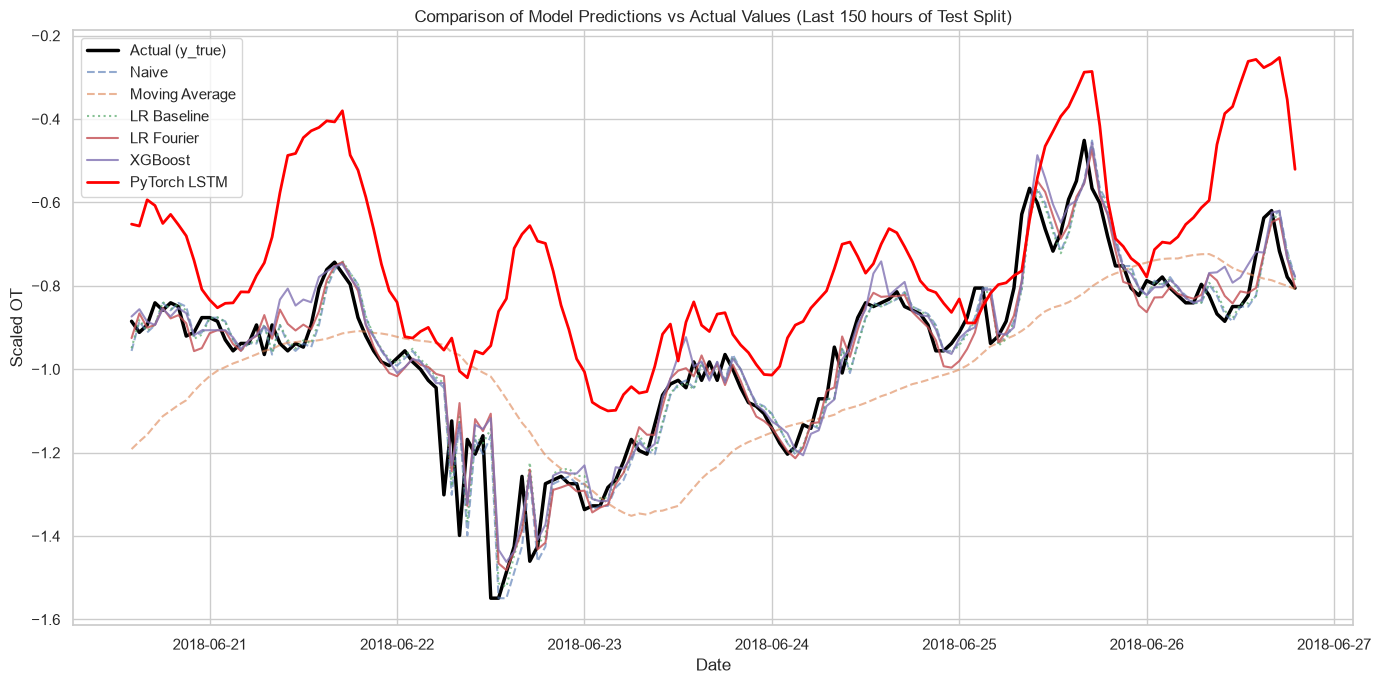

In [5]:
# We will plot the last 150 hours of the test set for visual clarity
plot_subset = pred_df.tail(150).reset_index(drop=True)

plt.figure(figsize=(14, 7))
plt.plot(plot_subset["date"], plot_subset["y_true"], label="Actual (y_true)", color="black", linewidth=2.5)
plt.plot(plot_subset["date"], plot_subset["naive"], label="Naive", linestyle="--", alpha=0.6)
plt.plot(plot_subset["date"], plot_subset["moving_average"], label="Moving Average", linestyle="--", alpha=0.6)
plt.plot(plot_subset["date"], plot_subset["linear_regression_baseline"], label="LR Baseline", linestyle=":", alpha=0.7)
plt.plot(plot_subset["date"], plot_subset["linear_regression_fourier"], label="LR Fourier", alpha=0.8)
plt.plot(plot_subset["date"], plot_subset["xgboost"], label="XGBoost", alpha=0.8)
plt.plot(plot_subset["date"], plot_subset["lstm"], label="PyTorch LSTM", color="red", linewidth=2.0)

plt.title("Comparison of Model Predictions vs Actual Values (Last 150 hours of Test Split)")
plt.xlabel("Date")
plt.ylabel("Scaled OT")
plt.legend(loc="upper left")
plt.grid(True)
plt.tight_layout()

os.makedirs("../figures", exist_ok=True)
plt.savefig("../figures/y_true_vs_y_pred.png", dpi=300)
plt.show()